# Project Goal

The objective of this exploratory data analysis is to understand
the characteristics of the Steel Industry Energy Consumption dataset
and identify important patterns that influence electricity usage.

The insights from this EDA will guide feature engineering,
data preprocessing and model selection for the regression task.

# Data Dictionary

| Feature                        | Meaning                 | Unit  |
| ------------------------------ | ----------------------- | ----- |
| date                           |                         | kWh   |
| Usage_kWh                      | Electricity consumption | kWh   |
| Lagging_Current_Reactive_Power | Reactive power          | kVarh |
| Leading_Current_Reactive_Power | Reactive power          | kVarh |
| CO2                            | Carbon emission         | ppm   |
| Lagging_Current_Power_Factor   | power factor            | %     |
| Leading_Current_Power_Factor   | power factor            | %     |
| NSM                            | Seconds after midnight  | sec   |
| WeekStatus                     | Weekend Weekday         |       |
| Day_of_week                    | Sunday, Monday ...      |       |



In [122]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown

from pathlib import Path
import sys


sys.path.append(str(Path.cwd().parent))

from src.data.make_dataset import load_data, get_data_overview, check_data, validate_data, clean_data, get_outlier_ratio
from src.visualization.visualize import plot_histogram, plot_box, plot_bar,  plot_scatter,analyze_distribution, plot_right_skewed_features, analyze_correlation


sys.path.append("..")

# -----------------------------
# Global styling
# -----------------------------
sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

palette = sns.color_palette("Set2") # Custom palette

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. Data  Overview
## 1.1 Load Data

In [123]:
df = load_data()
if df is not None:
    print(f"Loaded data:\n{df.head(3)}")
else:
    print(f"Data could not be loaded.")

Loaded data:
               date  Usage_kWh  Lagging_Current_Reactive.Power_kVarh  \
0  01/01/2018 00:15       3.17                                  2.95   
1  01/01/2018 00:30       4.00                                  4.46   
2  01/01/2018 00:45       3.24                                  3.28   

   Leading_Current_Reactive_Power_kVarh  CO2(tCO2)  \
0                                   0.0        0.0   
1                                   0.0        0.0   
2                                   0.0        0.0   

   Lagging_Current_Power_Factor  Leading_Current_Power_Factor   NSM  \
0                         73.21                         100.0   900   
1                         66.77                         100.0  1800   
2                         70.28                         100.0  2700   

  WeekStatus Day_of_week   Load_Type  
0    Weekday      Monday  Light_Load  
1    Weekday      Monday  Light_Load  
2    Weekday      Monday  Light_Load  


## 1.2 Data  Structure

In [124]:
if df is not None:
    rows, columns = get_data_overview(df)
   
    print(f"Data set has {rows} rows and {columns} columns.")
    

Data set has 35040 rows and 11 columns.


# 2. Data Validation
## 2.1 Basic Overview

In [125]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  str    
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  str    
 9   Day_of_week                           35040 non-null  str    
 10  Load_Type                             35040 non-null  str    
dtypes: float64(6), int64(1), s

## 2.2 Checking Missing Value and Duplicate Value

In [126]:
missing_value_msg, duplicated_rows_msg = check_data(df)
print(missing_value_msg)
print(duplicated_rows_msg)


There is no missing value in all columns.
No duplicated rows found in dataset.


## 2.3 Validating

In [127]:
col_num_unique_list, col_cat_unique_list = validate_data(df)


### 2.3.1 Validating Possible Unique Value and its Range in Numeric Variable

In [128]:
for col in col_num_unique_list:
    print(f"Numbers of unique '{col['column']}' value: {col['Total_Unique_Value']}, Range:{col['Max']} - {col['Min']}")

Numbers of unique 'Usage_kWh' value: 3343, Range:157.18 - 0.0
Numbers of unique 'Lagging_Current_Reactive.Power_kVarh' value: 1954, Range:96.91 - 0.0
Numbers of unique 'Leading_Current_Reactive_Power_kVarh' value: 768, Range:27.76 - 0.0
Numbers of unique 'CO2(tCO2)' value: 8, Range:0.07 - 0.0
Numbers of unique 'Lagging_Current_Power_Factor' value: 5079, Range:100.0 - 0.0
Numbers of unique 'Leading_Current_Power_Factor' value: 3366, Range:100.0 - 0.0
Numbers of unique 'NSM' value: 96, Range:85500 - 0


### 2.3.2 Validating Possible Unique Value in Object Type Variable

In [129]:
for col in col_cat_unique_list:
  print(f"Numbers of unique '{col['column']}' value: {col['Total_Unique_Value']} , Unique category list:{col['Unique_Cat_List']}")

Numbers of unique 'date' value: 35040 , Unique category list:<StringArray>
['01/01/2018 00:15', '01/01/2018 00:30', '01/01/2018 00:45',
 '01/01/2018 01:00', '01/01/2018 01:15', '01/01/2018 01:30',
 '01/01/2018 01:45', '01/01/2018 02:00', '01/01/2018 02:15',
 '01/01/2018 02:30',
 ...
 '31/12/2018 21:45', '31/12/2018 22:00', '31/12/2018 22:15',
 '31/12/2018 22:30', '31/12/2018 22:45', '31/12/2018 23:00',
 '31/12/2018 23:15', '31/12/2018 23:30', '31/12/2018 23:45',
 '31/12/2018 00:00']
Length: 35040, dtype: str
Numbers of unique 'WeekStatus' value: 2 , Unique category list:<StringArray>
['Weekday', 'Weekend']
Length: 2, dtype: str
Numbers of unique 'Day_of_week' value: 7 , Unique category list:<StringArray>
['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
Length: 7, dtype: str
Numbers of unique 'Load_Type' value: 3 , Unique category list:<StringArray>
['Light_Load', 'Medium_Load', 'Maximum_Load']
Length: 3, dtype: str


It can be observed that the `Date` column is not stored in the correct data type. Therefore, it should be converted to the datetime data type before further analysis.

In [130]:
# clean data
df = clean_data(df)
print(f"Clean Data:\n {df.head(3)}")

Clean Data:
    Usage_kWh  Lagging_Current_Reactive.Power_kVarh  \
0       3.17                                  2.95   
1       4.00                                  4.46   
2       3.24                                  3.28   

   Leading_Current_Reactive_Power_kVarh  CO2(tCO2)  \
0                                   0.0        0.0   
1                                   0.0        0.0   
2                                   0.0        0.0   

   Lagging_Current_Power_Factor  Leading_Current_Power_Factor   NSM  \
0                         73.21                         100.0   900   
1                         66.77                         100.0  1800   
2                         70.28                         100.0  2700   

  WeekStatus Day_of_week   Load_Type       consumed_date  
0    Weekday      Monday  Light_Load 2018-01-01 00:15:00  
1    Weekday      Monday  Light_Load 2018-01-01 00:30:00  
2    Weekday      Monday  Light_Load 2018-01-01 00:45:00  


# 3. Exploratory Analysis
## 3.1 Univariate Analysis - Target Variable
As the goal of this project is to predict energy consumption in the steel factory, column '`Usage_kWh`' which indicates industry energy consumption would be target variable.

In [131]:
# Define target variable
target = 'Usage_kWh'

### 3.1.1 Target Distribution
After target variable is determined, a histogram chart is plotted to know its distribution.

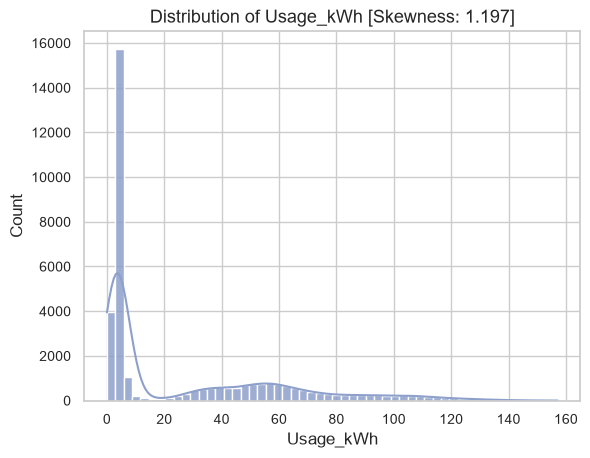

In [132]:
title = f"Distribution of {target} [Skewness: {round(df[target].skew(),3)}]"
plot_histogram(df, target, title)

### 3.1.2 Detecting Outliers in Target

The distribution is right-skewed with several high-consumption observations. These likely correspond to periods of maximum industrial load rather than measurement errors, so they are retained.

### 3.1.2 Log Transformation

As the target data is highly right-skewed, a log transformation is applied to the target column.

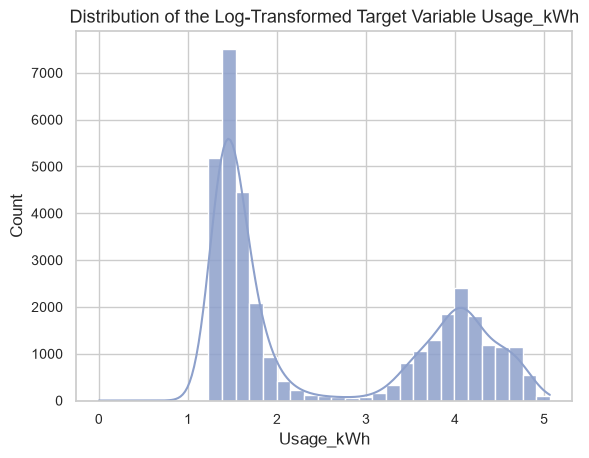

In [133]:
title = f"Distribution of the Log-Transformed Target Variable {target}"
plot_histogram(df, target, title,True)

After plotting the log-transformed target variable, the distribution became more compact, which can improve the performance of many machine learning models.

However, as shown in the plot, the distribution has two distinct peaks and does not exhibit a Gaussian shape, indicating that it is not normally distributed. Instead, it appears to be bimodal. The first peak is around 0.45–0.60, while the second peak is around 1.70–1.90.

This indicates that data likely comes from two different groups or operation condition rather than single homogenous population. 

I decided to find out possible explanation what these dominant factors are — as they may significantly influence the electricity consumption.

Further analysis should examine these variables to identify the source of two consumption pattern.

# 3. Statistical Summary

The descriptive statistical summary is stated and the distribution graph is plotted to obtain the clear data pattern of numeric features.


In [134]:
df.describe()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,consumed_date
count,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040
mean,27.386892,13.035384,3.870949,0.011524,80.578056,84.367870,42750.000000,2018-07-02 11:52:30
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2018-01-01 00:00:00
25%,3.200000,2.300000,0.000000,0.000000,63.320000,99.700000,21375.000000,2018-04-02 05:56:15
50%,4.570000,5.000000,0.000000,0.000000,87.960000,100.000000,42750.000000,2018-07-02 11:52:30
75%,51.237500,22.640000,2.090000,0.020000,99.022500,100.000000,64125.000000,2018-10-01 17:48:45
max,157.180000,96.910000,27.760000,0.070000,100.000000,100.000000,85500.000000,2018-12-31 23:45:00
std,33.444380,16.306000,7.424463,0.016151,18.921322,30.456535,24940.534317,NaN


# 4. Features Distribution

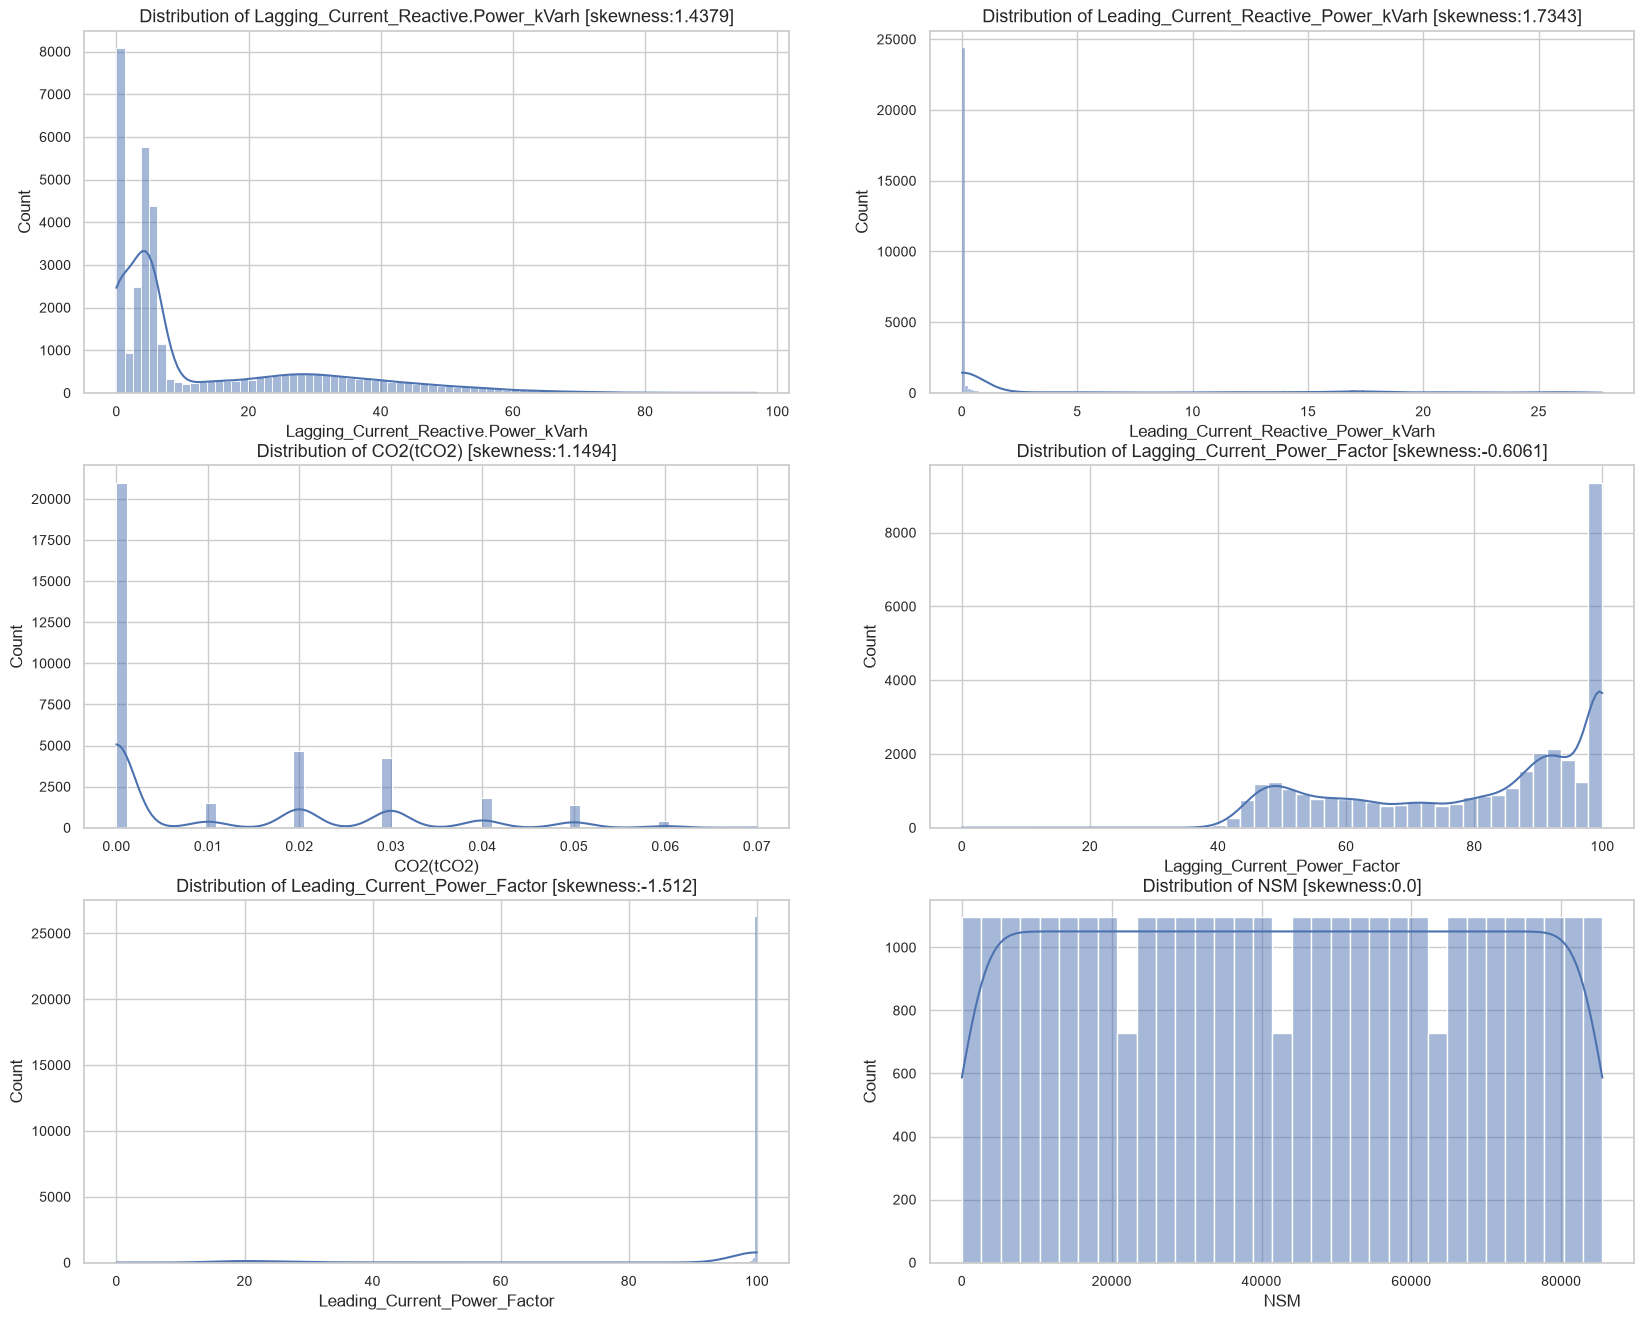

In [135]:

col_num = df.select_dtypes(include=['float64','int64']).columns.tolist()
col_num = [c for c in col_num if c != target]

left_skew_feat, right_skew_feat = analyze_distribution(df,col_num)

According to the aboved features distribution graphs, two groups of features with right-skewed and features with left-skewed can be formed for further analysis.

In [136]:
print(f"Right skewed features:{right_skew_feat}")
print(f"Left skewed features:{left_skew_feat}")

Right skewed features:['Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)']
Left skewed features:['Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor']


## 4.2 Detecting Outliers in features
### 4.2.1 Reactive power
- `Lagging_Current_Reactive.Power_kVarh`
- `Leading_Current_Reactive_Power_kVarh`	

These features likely contain large spikes, so that I further investigate whether they occur during maximum load.


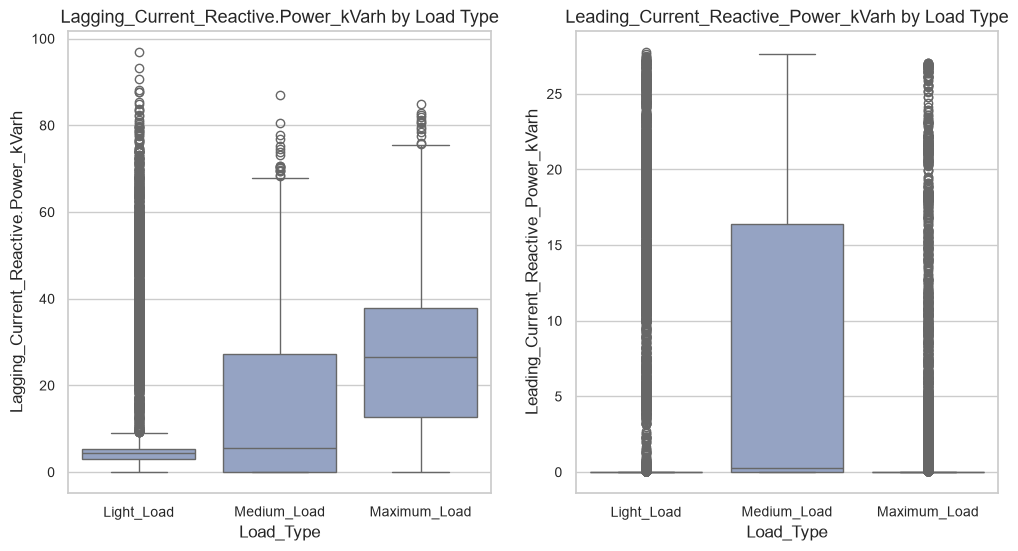

In [137]:
detect_outliers_feature = ['Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh']

plot_box(df, 'Load_Type', detect_outliers_feature)

According to the aboved box plot, maximum load generally operate with higher lagging reactive power and it has a much higher distribution. But the highest values are not only in maximum load, the plot clearly show that some high lagging reactive power observations are under light load as well.

But for leading reactive power, medium load obviously has most of the highest power values.

I also investigated outlier ratio to make sure whether statistical outlier occured in both lagging reactive power and leading reactive power.


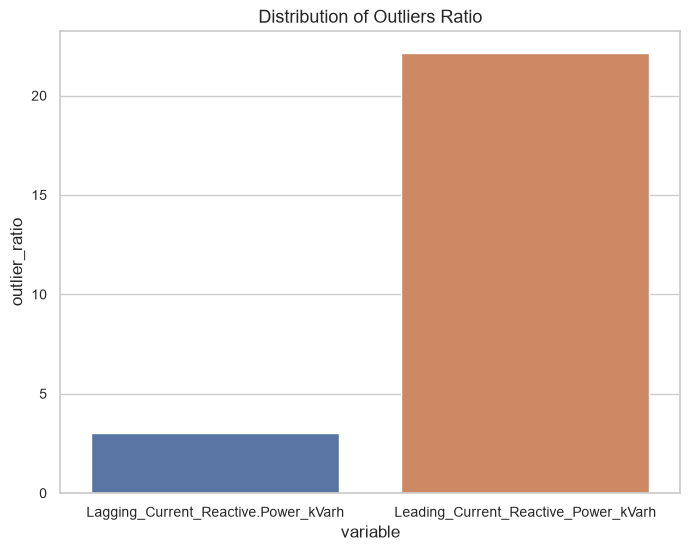

In [138]:
# get outlier ratio for reactive power features
df_outlier = get_outlier_ratio(df,detect_outliers_feature)

# plot distribution of outlier ratio
title='Distribution of Outliers Ratio'
plot_bar(df_outlier, 'variable', 'outlier_ratio', 'variable', 'outlier_ratio', title)


For lagging reactive power, its outlier ratio 3.02% is obviously small and it is generally considered as common and acceptable as this is industrial energy consumption data not a survey or transaction data.
And is higher value mostly occur in maximum load type which usually indicated heavy machinery operatiing so that I decided to retained it.

The `Leading_Current_Reactive_Power_kVarh` variable exhibits an outlier ratio of approximately 22.1% according to the IQR rule. However, according to its distribution graph, it is highly right-skewed with many observations concentrated near zero, a sensible trend with energy consumption for leading reactive power in industrial electrical systems. Therefore, these observations are not treated as erroneous values so I decided to apply a logarithmic transformation to reduce skewness while preserving potentially informative extreme values.


In [139]:
print(f"Percentage of zero leading reactive power:{round((df['Leading_Current_Reactive_Power_kVarh'] ==0).mean() * 100 ,2)} %")

Percentage of zero leading reactive power:67.38 %


### 4.2.2 Power factor
- `Lagging_Current_Power_Factor`	
- `Leading_Current_Power_Factor`

Lagging and leading power factor likely to be within the standard range between 0 and 100. I would not perform traditional IQR-based outlier removal method on these feature.

In [140]:
print(f"Lagging power factor:\n{df['Lagging_Current_Power_Factor'].describe()}")
print(f"\nLagging power factor:\n{df['Leading_Current_Power_Factor'].describe()}")

Lagging power factor:
count    35040.000000
mean        80.578056
std         18.921322
min          0.000000
25%         63.320000
50%         87.960000
75%         99.022500
max        100.000000
Name: Lagging_Current_Power_Factor, dtype: float64

Lagging power factor:
count    35040.000000
mean        84.367870
std         30.456535
min          0.000000
25%         99.700000
50%        100.000000
75%        100.000000
max        100.000000
Name: Leading_Current_Power_Factor, dtype: float64



## 4.3 Log Transformation to Right-Skewed Features

According to the distribution graph, some features are highly right-skewed, while others are highly left-skewed. I applied a log transformation to the right-skewed features. For features containing very small or negative values, I used the `Yeo–Johnson` transformation via `PowerTransformer` to reduce skewness, as it can handle both positive and negative values.

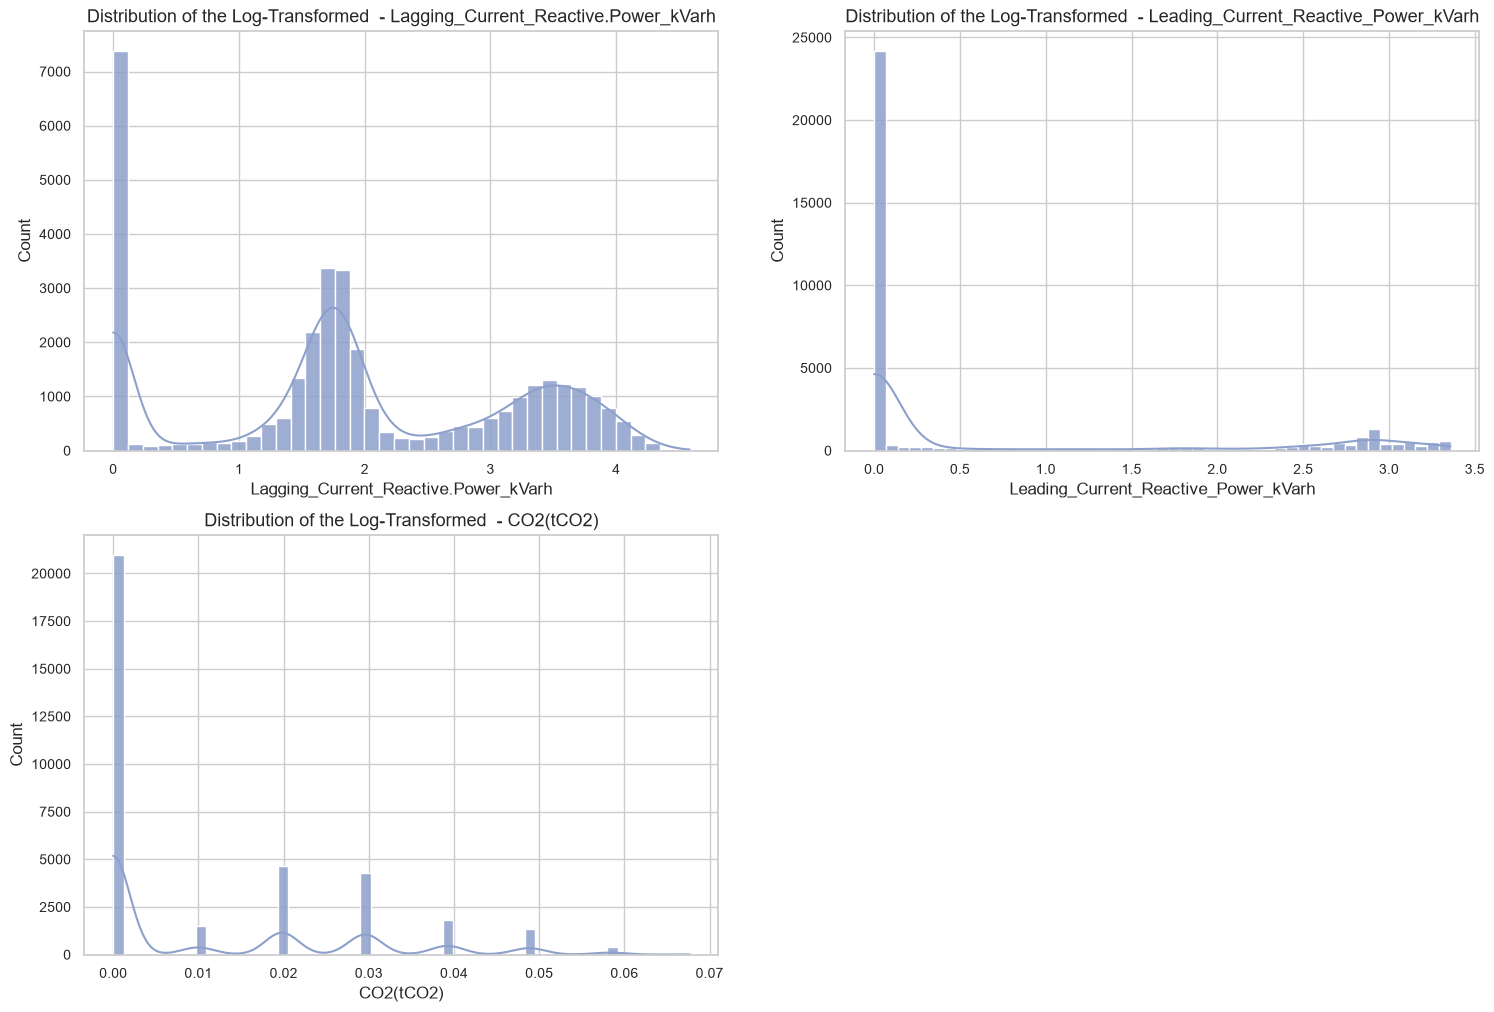

In [141]:
title = f"Distribution of the Log-Transformed "

plot_right_skewed_features(right_skew_feat, df, title)

## 4.4 Yeo-Johnson Transformation to Left-Skewed Features

However, for left-skewed features, the Yeo-Johnson transformation should not be applied on the full dataset, as it tries to find the optimal λ parameter — the value that makes the resulting distribution as Gaussian as possible. This causes **data leakage**, so I decided to split the data first and then apply the transformation on the **training dataset only** in feature engineering section.

# 5. Correlation Analysis 
## 5.1 Numerical variables Vs Target



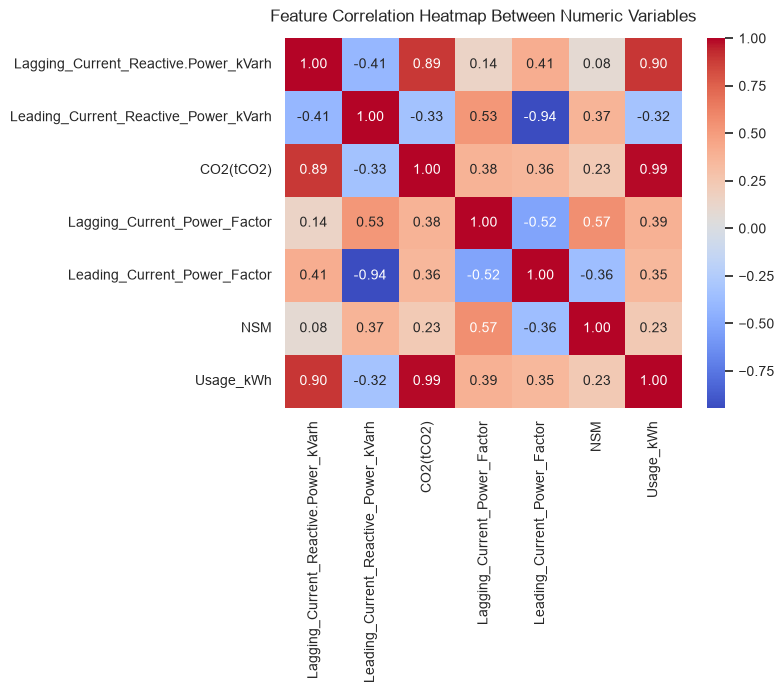

Lagging_Current_Reactive.Power_kVarh    0.896150
Leading_Current_Reactive_Power_kVarh   -0.324922
CO2(tCO2)                               0.988180
Lagging_Current_Power_Factor            0.385960
Leading_Current_Power_Factor            0.353566
NSM                                     0.234610
Name: Usage_kWh, dtype: float64

In [142]:
col_num_with_target = col_num + [target]

corr_target = analyze_correlation(df, col_num_with_target, target)
corr_target

Obviously, it can be seen that two features : `Lagging_Current_Reactive` and `CO2` have high positive linear relationship with target variable `Usage_kWh`.
There is moderate negative linear relationship between target and `Leading_Current_Reactive_Power`. 

To further investigate the relationship between features and target variable, I choose to make scatter plot to compare median and spread of each feature against with energy consumption.



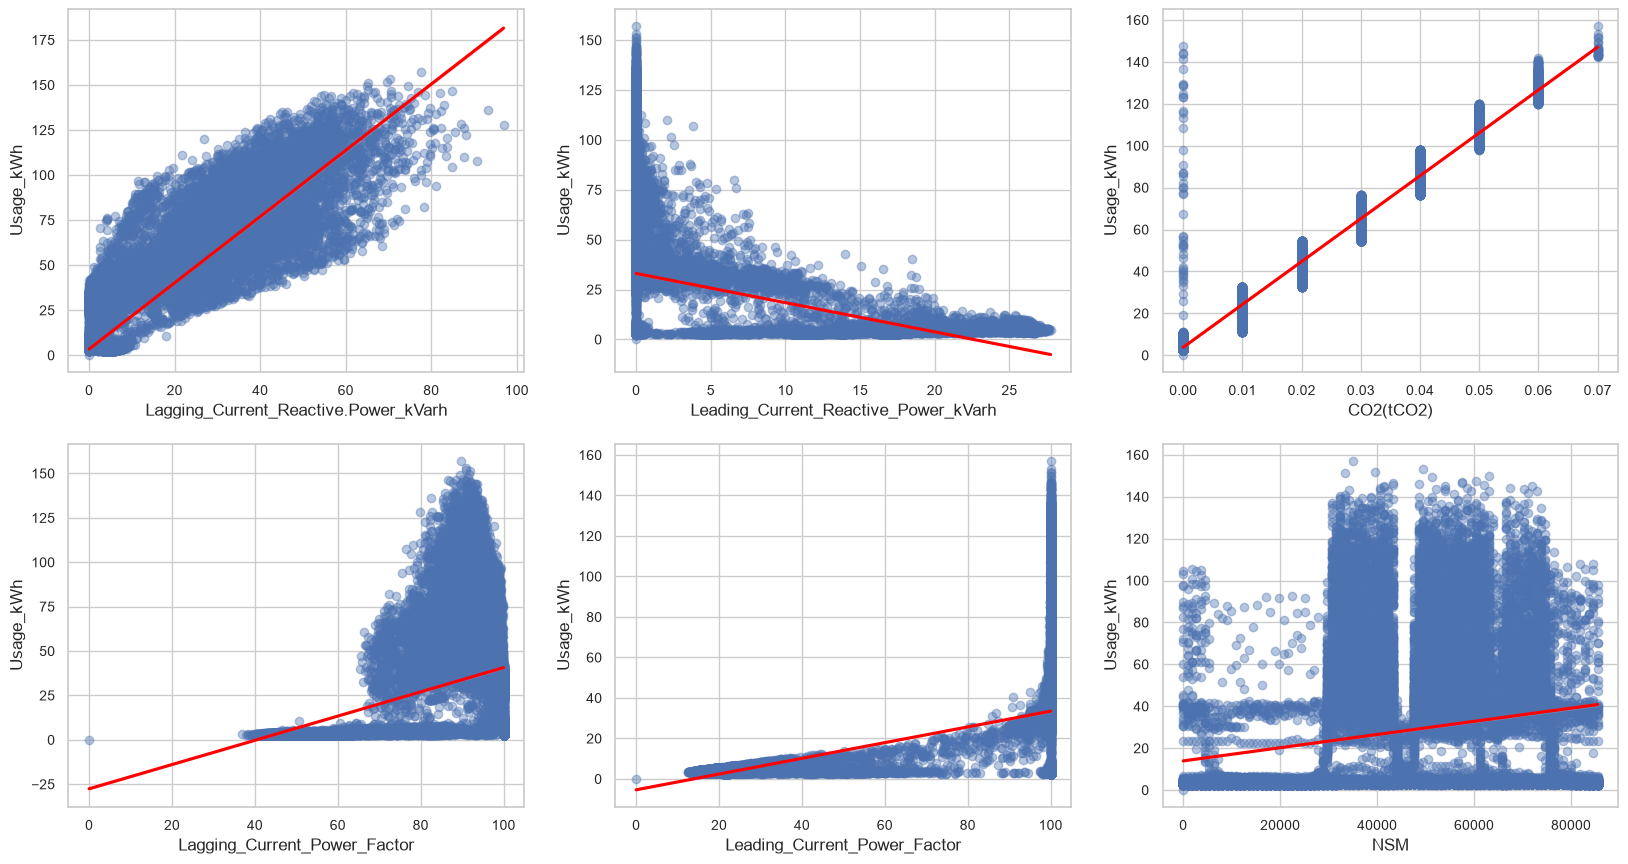

In [143]:
# scatter plot to compare spread of features
plot_scatter(df, col_num,target)

According to the boxplots for each feature, relationship with `CO2` and target is almost perfect. There is strong positive relationship with `Lagging_Current_Reactive` and target, and it tends to be the strongest predictor and variance increase as its value increases. 
- `Lagging_Current_Reactive_Power` - Strong positive relationship, need to **apply log transformation**.
- `Leading_Current_Reactive_Power` - Weak and negative relationship, **many zeros value**, most of the machine do not produce leading reactive power.
- `CO2` - **perfect linear relationship**, it seems to be calculated directiy from electrical usage. If it is true, this feature should be eliminated, there might be target leakage issue because it already contain information about the usage.
- `Lagging_Current_Power_Factor` - Positive highly non-linear relationship, value **clustered around 70 to 100**
- `Leading_Current_Power_Factor` - Most observation is value 100, very little variation. So **information content very low**. 
- `NSM` (Number of seconds from Midnight) - Data pattern is **interesting** although it is not a smooth trend. Usage changes during different period of the day


## 5.2 Categorical variables Vs Target

In [144]:
col_cat = df.select_dtypes(include=['object','str']).columns.tolist()
print(f"Categorical Features: {col_cat}")

Categorical Features: ['WeekStatus', 'Day_of_week', 'Load_Type']


It is important to know that distribution of average electrical consumption usage across the load type and week status.

From the graph below, maximum load type obviously consume large amount of electricity.
And as per usual manufacturing industry, production shift on week days use higher electricity compare with weekend shift.

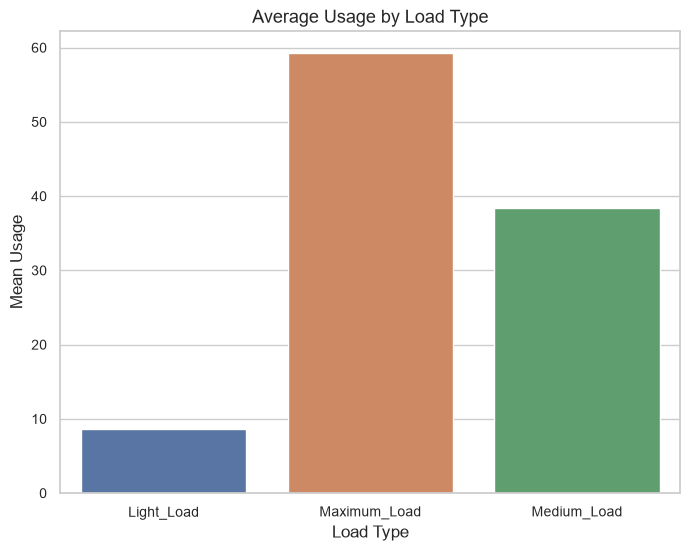

In [145]:
# bar plot for distribution of mean usage by load type
df_grp_loadtype = (
    df.groupby("Load_Type")[target]
      .agg(["count", "mean", "min", "max"])
      .reset_index()
)

plot_bar(df_grp_loadtype, 'Load_Type', 'mean', 'Load Type', 'Mean Usage', 'Average Usage by Load Type')

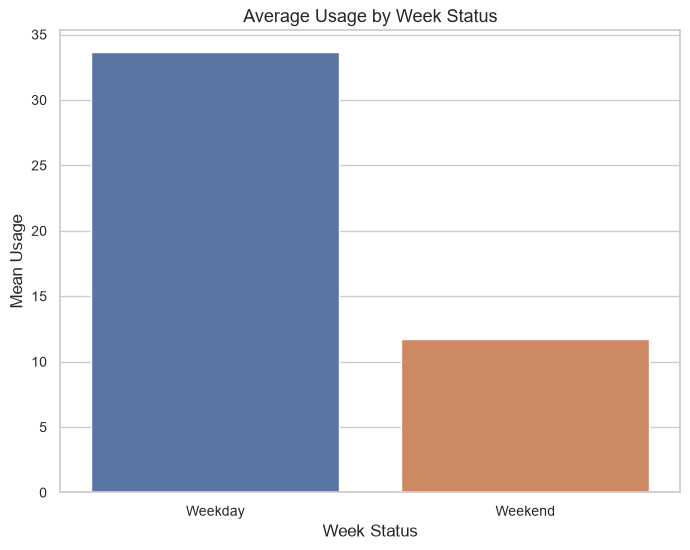

In [146]:
# bar plot for distribution of mean usage by week status
df_grp_weekstatus = (
    df.groupby("WeekStatus")[target]
      .agg(["count", "mean", "min", "max"])
      .reset_index()
)

plot_bar(df_grp_weekstatus, 'WeekStatus', 'mean', 'Week Status', 'Mean Usage', 'Average Usage by Week Status')

# 6. Conclusion on EDA Findings

Based on the aboved-mentioned analysis on various factor, I concluded the followings key findings for this EDA notebook.
Key Findings
- No missing values.

- Date converted into datetime.

- Target feature `Usage_kWh` is strongly right-skewed, and it is strongly correlated with Lagging Current,
CO2 and NSM.

- Several variables exhibit skewness and benefit from
log or Yeo-Johnson transformations.

- High-load observations appear to be legitimate production
events and are retained.

- Weekdays consume more electricity.

- Light load periods consume significantly less energy.

- Time-related features are expected to improve predictive
performance.

- Additional temporal features should be engineered.

These findings will guide preprocessing and feature engineering
for subsequent regression modelling.